In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from functools import reduce
import matplotlib.ticker as mtick
import calendar
from datetime import date
import pathlib
from pathlib import Path
from datetime import datetime, timedelta
import os
from matplotlib.ticker import StrMethodFormatter


import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\aallen\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\aallen\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [96]:
#Notes
#Confirm reported electricity use is in kWh before running 
analysis_year = 2025 
timesteps_per_hr = 1
sim_length = 8760 *timesteps_per_hr
steam_htg_value = 930 #btu/lb, based on paul's report of conditions 15 to 50 psi at buildings
btu_per_kWh = 3412.14 
wh_to_lbs = 0.001 * btu_per_kWh * 1/steam_htg_value #use this for steam conversions since thermal load outputs are in W
kbtu_to_therms = 1/100 #use for NG if UO output is in kBTU 
steam_heat_ex_eff = 0.7 #used for conversion from HW heating loads to steam 


In [94]:
wh_to_lbs

0.003922

In [60]:
def calc_load_profile_spec(dir_path, id, end_use):
    target_string = "default_feature_reports"
    file_name = "default_feature_reports.csv"
    tab_load_x = np.full((sim_length, 1), np.nan)

    # Create the DataFrame using the NumPy array and column names
    tab_load = pd.DataFrame(tab_load_x, columns=['test'])
    tab_sum = 0 
    
    for fol in dir_path.iterdir():
        if (fol.is_dir() and id in fol.name):
            for folder in fol.iterdir():
               if folder.is_dir() and target_string in folder.name:
                new_dir_path = os.path.join(dir_path, fol, folder)
                path_to_file = Path(new_dir_path) / file_name
                loads = pd.read_csv(path_to_file)
                if end_use == 'Electricity':
                    tab_inc = loads['Electricity:Facility(kWh)']
                    tab_load[id] = tab_inc 
                    tab_sum = tab_load.sum(axis=1).sum()
                elif end_use == 'Natural Gas':
                    tab_inc = loads['NaturalGas:Facility(kBtu)']
                    tab_load[id] = tab_inc 
                    tab_sum = tab_load.sum(axis=1).sum()
                tab_load = tab_load.drop(columns=['test'])
    return [tab_load, tab_sum] 

In [5]:
def calc_monthly_sums(year, timesteps_per_hr, load_profile, unit_conv, end_use, steam_heat_ex_eff=0.7): #for electricity outputs already in kWh, use 1.0 as unit_conv
    start_dt = date(year, 1,1)
    end_dt = date(year+1, 1,1)
    if timesteps_per_hr == 1:
       dates = pd.date_range(start=start_dt, end=end_dt, freq='h')
    elif timesteps_per_hr == 4:
       dates = pd.date_range(start=start_dt, end=end_dt, freq='15min')
    else:
       return "timestep not supported"
 
    dates = dates[:-1] #getting an extra last entry, need to drop
    
    working_df = load_profile.set_index(dates)
    if end_use == 'Electricity' or end_use == 'Natural Gas':
        monthly_df = working_df.resample('MS').sum()*unit_conv
    elif end_use == 'Steam':
         monthly_df = working_df.resample('MS').sum()*unit_conv/((timesteps_per_hr)*steam_heat_ex_eff) #Integrating W values to watt-hours 
    
    return working_df, dates, monthly_df

In [52]:
def plot_monthly(id, load_profile, end_use): #Note, output aggregates monthly totals under month start date
    buffer = pd.DateOffset(months=1)  
    if end_use == 'Electricity' or end_use == 'Natural Gas':
        y_max = load_profile[id].max() * 1.2 
    elif end_use == 'Steam':
        y_max = load_profile['htg_tot'].max() * 1.2 
    ax = plt.gca()
    if end_use == 'Electricity' or end_use == 'Natural Gas':
        plt.xlim(load_profile[id].index[0] - buffer, load_profile[id].index[-1] + buffer)
        ax.set_xticks(load_profile[id].index[::2])
    elif end_use == 'Steam':
        plt.xlim(load_profile['htg_tot'].index[0] - buffer, load_profile['htg_tot'].index[-1] + buffer)
        ax.set_xticks(load_profile['htg_tot'].index[::2])
    plt.grid()
    plt.ylim(0, y_max)
    plt.xlim()
    if end_use == 'Electricity':
        plt.ylabel('Electricity consumption (kWh)')
        plt.plot(load_profile[id], label=f'Modeled {end_use}')
    elif end_use == 'Steam':
        plt.ylabel('Steam (lbs)')
        plt.plot(load_profile['htg_tot'], label=f'Modeled {end_use}')
    elif end_use == 'Natural Gas':
        plt.ylabel('Natural gas (therms)')
        plt.plot(load_profile[id], label=f'Modeled {end_use}')
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    plt.xticks(rotation=45, ha='right') 
    plt.legend()

In [84]:
def calc_thermal_load_profile_spec_post_proc_file(file): #Don't use for now, for a specific case and needs DHW added
    target_string = "default_feature_reports"
    file_name = "default_feature_reports.csv"
    elec_load_x = np.full((sim_length, 1), np.nan)

    # Create the DataFrame using the NumPy array and column names
    thermal_prof = pd.DataFrame(elec_load_x, columns=['test'])
    str1='coil'
    str2='heat'
    str3='reheat'
    str4='cooling coil ice thermal storage'
    str5='cool'
    str6='clg'
    str7='htg'
    str8 ='main'
    

    loads = file
    htg_columns = [col for col in loads.columns if str1 in col.lower() and str8 in col.lower() and 
                   ((str2 in col.lower()) and (str7 in col.lower())) and (str4 not in col.lower()) and (str3 not in col.lower())
    ]
    #for col in htg_columns: #can turn this on for QC
#                     print(col)
#                     print(len(htg_columns))
    clg_columns = [
    col for col in loads.columns
    if str1 in col.lower() and ((str5 in col.lower()) or (str6 in col.lower())) and (str4 not in col.lower())
     ]
#                 for col in clg_columns: #can turn this on for QC
#                     print(col)
#                     print(len(clg_columns))
    htg_prof = loads[htg_columns].sum(axis=1)
    clg_prof = loads[clg_columns].sum(axis=1)
    thermal_prof['htg'] = htg_prof
    thermal_prof['clg'] = clg_prof 
    thermal_prof = thermal_prof.drop(columns=['test'])

    return thermal_prof

In [92]:
def calc_thermal_load_profile_spec(dir_path, id): #Use this one to extract thermal loads
    target_string = "default_feature_reports"
    file_name = "default_feature_reports.csv"
    elec_load_x = np.full((sim_length, 1), np.nan)

    # Create the DataFrame using the NumPy array and column names
    thermal_prof = pd.DataFrame(elec_load_x, columns=['test'])
    str1='coil'
    str2='heat'
    str3='reheat'
    str4='cooling coil ice thermal storage'
    str5='cool'
    str6='clg'
    str7='htg'
    str8='service'
    str9='water'
    str10='loop'
    str11='domestic'
    str12='dhw'
    
    for fol in dir_path.iterdir():
        if (fol.is_dir() and id in fol.name):
            for folder in fol.iterdir():
               if folder.is_dir() and target_string in folder.name:
                new_dir_path = os.path.join(dir_path, fol, folder)
                path_to_file = Path(new_dir_path) / file_name
                loads = pd.read_csv(path_to_file)
                htg_columns = [col for col in loads.columns if str1 in col.lower() and
                               ((str2 in col.lower()) or (str3 in col.lower()) or (str7 in col.lower())) and (str4 not in col.lower())
                ]
                #for col in htg_columns: #can turn this on for QC
#                     print(col)
#                     print(len(htg_columns))
                clg_columns = [
                col for col in loads.columns
                if str1 in col.lower() and ((str5 in col.lower()) or (str6 in col.lower())) and (str4 not in col.lower())
                 ]
#                 for col in clg_columns: #can turn this on for QC
#                     print(col)
#                     print(len(clg_columns))
                #find dhw columns 
                dhw_column = [col for col in loads.columns
                if str11 in col.lower() or str12 in col.lower() or ((str8 in col.lower()) and (str9 in col.lower()))] 
                #print(dhw_column)  #can turn on for qc 
                dhw_prof = loads[dhw_column].sum(axis=1)
                space_htg_prof = loads[htg_columns].sum(axis=1)
                clg_prof = loads[clg_columns].sum(axis=1)
                thermal_prof['dhw'] = dhw_prof
                thermal_prof['space_htg'] = space_htg_prof
                thermal_prof['clg'] = clg_prof 
                thermal_prof['htg_tot'] = thermal_prof['space_htg'] + thermal_prof['dhw']
                thermal_prof = thermal_prof.drop(columns=['test'])

    return thermal_prof

In [77]:
#set file paths
dir_path_test = Path('C:/Users/aallen/...../createbar_scenario_mod_properties_v8_661_only/') #replace with path to folder within UO "run" folder 
dir_path_test_2 = Path('C:/Users/aallen/..../createbar_scenario_mod_properties_v8_434_only_off/')
id_test = "a20539dd-f643-4532-847a-4fd15663f1bc"
id_test_2 = '01c99d14-837d-487e-944c-d761eb786a5c'

In [78]:
#calculate load profiles
elec_load_01c = calc_load_profile_spec(dir_path_test, id_test_2, 'Electricity')[0]
elec_sum_01c = calc_load_profile_spec(dir_path_test, id_test_2, 'Electricity')[1]
a20_ng_profile = calc_load_profile_spec(dir_path_test_2, id_test, 'Natural Gas')[0]

In [91]:
#extract thermal loads
thermal_prof_01c = calc_thermal_load_profile_spec(dir_path_test, id_test_2)

In [86]:
#create monthly sums 
month_sums_01c_elec = calc_monthly_sums(analysis_year, timesteps_per_hr, elec_load_01c, 1, 'Electricity')[2]
month_sums_a20_ng = calc_monthly_sums(analysis_year, timesteps_per_hr, a20_ng_profile, kbtu_to_therms, 'Natural Gas')[2]
month_sums_01c_steam = calc_monthly_sums(analysis_year, timesteps_per_hr, (thermal_prof_01c['htg_tot']).to_frame() , wh_to_lbs, 'Steam')[2]

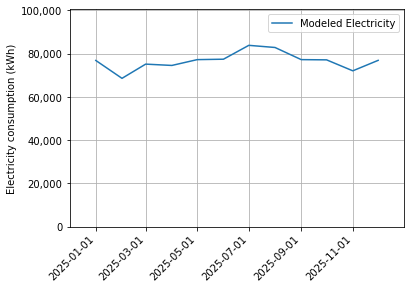

In [87]:
#plot monthly elec 
plot_monthly(id_test_2,month_sums_01c_elec, 'Electricity')




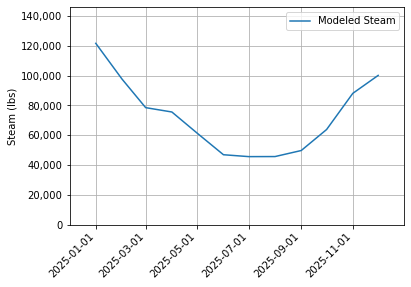

In [88]:
#plot monthly steam
plot_monthly(id_test_2, month_sums_01c_steam, 'Steam')

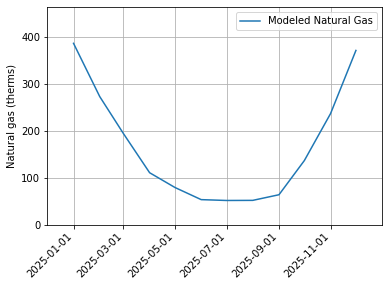

In [89]:
#plot monthly NG
plot_monthly(id_test, month_sums_a20_ng, 'Natural Gas')